# File 7 — Risk Index v2 & Scenario Simulation

**Project:** Irish Crime Intelligence Platform

---

## What this file does

This is the final file in the pipeline. Everything we built across Files 1 to 6 — the risk metrics, cluster labels, forecasts, and early warning flags — gets combined into one master table here.

From that table we build an improved risk index and run three scenario simulations to answer a real planning question: which Garda stations deserve priority attention, and why?

## Why this file exists

Files 1 to 6 each answered one specific question. File 7 is where we bring all those answers together and turn them into something a decision maker can actually use.

## Objectives
1. Build a master station table combining all previous outputs
2. Build Risk Index v2 — an improved version that adds forecast and crime complexity signals
3. Assign every station a risk tier
4. Run three scenario simulations under different planning assumptions
5. Write a final analyst recommendation

## Data we are using
| File | What we need |
|---|---|
| `station_risk_metrics_full.csv` | recent volume, growth rate, normalised components from File 2 |
| `Garda_Station_Strategy_Master.csv` | cluster labels, urban flag, offence concentration from File 3 |
| `station_forecasts.csv` | 2025 forecast per station from File 6 |
| `early_warning_stations.csv` | growth alert, pressure alert, warning score from File 6 |

## What we produce
| File | What it contains |
|---|---|
| `station_decision_table.csv` | master table — all 564 stations with every metric |
| `station_risk_index_v2.csv` | improved risk scores and tier for every station |
| `priority_stations_national_top20.csv` | top 20 highest risk stations nationally |
| `priority_stations_outside_dublin.csv` | high risk stations outside Dublin |
| `priority_stations_emerging_pressure.csv` | stations showing early warning signs of becoming high risk |

---
## Section 1 — Setup and Load Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from matplotlib.patches import Patch

pd.set_option('display.max_columns', 50)
print('all good')

all good


In [22]:
# load all 4 input files
risk        = pd.read_csv('station_risk_metrics_full.csv')
master      = pd.read_csv('Garda_Station_Strategy_Master.csv')
forecasts   = pd.read_csv('station_forecasts.csv')
warnings_df = pd.read_csv('early_warning_stations.csv')

print('risk metrics   :', risk.shape)
print('station master :', master.shape)
print('forecasts      :', forecasts.shape)
print('early warnings :', warnings_df.shape)

risk metrics   : (564, 16)
station master : (564, 11)
forecasts      : (100, 10)
early warnings : (50, 13)


---
## Section 2 — Build Master Decision Table

Every station gets one row with every metric we have built across the pipeline. This is the single source of truth for everything in this file.

Merging 4 files together step by step so it is easy to follow.

In [23]:
# start from the risk metrics - this has all 564 stations so it is a safe base
base = risk[[
    'station_code', 'station_name', 'station_division', 'county',
    'incidents_recent', 'incidents_hist', 'growth_rate', 'growth_rate_filled',
    'recent_norm', 'growth_norm', 'risk_index', 'rank_risk', 'new_activity_flag'
]].copy()

print('starting with', len(base), 'stations')

starting with 564 stations


In [24]:
# bring in cluster labels and offence concentration from the strategy master
# we built these in File 3

cluster_cols = master[[
    'station_code', 'strategy_cluster', 'urban_station_flag',
    'offence_concentration_index', 'percent_national_volume',
    'emerging_offence_groups', 'share_offences_with_positive_growth'
]].copy()

base = base.merge(cluster_cols, on='station_code', how='left')

print('after adding cluster info:', base.shape)
print('any missing cluster labels?', base['strategy_cluster'].isna().sum(), '— should be 0')

after adding cluster info: (564, 19)
any missing cluster labels? 0 — should be 0


In [25]:
# bring in 2025 forecasts from File 6
# the forecasts file has 2 rows per station (2025 and 2026) so filter to 2025 only

fc_2025 = forecasts[forecasts['year'] == 2025][[
    'station_code', 'forecast_incidents', 'lower_ci', 'upper_ci', 'model_used'
]].copy()

fc_2025 = fc_2025.rename(columns={
    'forecast_incidents': 'forecast_2025',
    'lower_ci':           'forecast_lower',
    'upper_ci':           'forecast_upper'
})

base = base.merge(fc_2025, on='station_code', how='left')

has_forecast    = base['forecast_2025'].notna().sum()
no_forecast     = base['forecast_2025'].isna().sum()

print('stations with a 2025 forecast:', has_forecast, '(top 50 high risk stations)')
print('stations without forecast     :', no_forecast, '(lower risk stations - not in top 50)')

stations with a 2025 forecast: 50 (top 50 high risk stations)
stations without forecast     : 514 (lower risk stations - not in top 50)


In [26]:
# bring in early warning flags from File 6
ew_cols = warnings_df[[
    'station_code', 'recent_annual_avg',
    'growth_alert', 'pressure_alert', 'warning_score'
]].copy()

base = base.merge(ew_cols, on='station_code', how='left')

# stations not in top 50 won't have warning flags - fill with 0
# this means no alert, not missing data
base['growth_alert']   = base['growth_alert'].fillna(0).astype(int)
base['pressure_alert'] = base['pressure_alert'].fillna(0).astype(int)
base['warning_score']  = base['warning_score'].fillna(0).astype(int)

print('master table ready:', base.shape)
print('stations with growth alert  :', base['growth_alert'].sum())
print('stations with both alerts   :', (base['warning_score'] == 2).sum())

decision_table = base.copy()

master table ready: (564, 27)
stations with growth alert  : 7
stations with both alerts   : 5


---
## Section 3 — Risk Index v2

### Why are we building a new risk index?

In File 2 we built Risk Index v1. The formula was:

`Risk Index v1 = 0.6 × recent volume + 0.4 × growth rate`

That was a good starting point but it had two problems:
1. It only looked backwards — no forward-looking signal at all
2. It ignored how complex the crime mix at a station is — two stations with identical volume could have very different operational demands

Now that we have File 6 forecasts and File 3 cluster outputs we can fix both of those problems.

### Risk Index v2 formula

| Component | Weight | Why this weight |
|---|---|---|
| Recent volume | 35% | Current workload is still the most important signal |
| Historical growth rate | 25% | Past trajectory tells us where a station has been heading |
| Forecast growth | 20% | Where the station is expected to go in 2025 — the new signal |
| Offence concentration | 20% | A station with many different offence types is operationally more complex than one with one dominant offence |

The weights add to 100%. Recent volume is still weighted highest because it reflects real current demand. The forecast and concentration components together make up 40% — meaningful enough to shift rankings but not so dominant that they override the actual workload picture.

### What changes from v1 to v2?

Stations that were growing fast historically AND are forecast to keep growing will move up in the ranking. Stations that had high volume in the past but are now flat or declining will drop slightly. This gives planners a more honest forward-looking picture.

In [27]:
# normalise forecast_2025 to 0-1 range so it is on the same scale as the other components
# stations without a forecast get 0 — conservative assumption, not penalised but not boosted

f_min = decision_table['forecast_2025'].min()
f_max = decision_table['forecast_2025'].max()

decision_table['forecast_norm'] = (
    (decision_table['forecast_2025'] - f_min) / (f_max - f_min)
).fillna(0)  # fillna(0) handles stations not in top 50

# same for offence concentration
hhi_min = decision_table['offence_concentration_index'].min()
hhi_max = decision_table['offence_concentration_index'].max()

decision_table['hhi_norm'] = (
    (decision_table['offence_concentration_index'] - hhi_min) / (hhi_max - hhi_min)
)

print('forecast_norm range :', round(decision_table['forecast_norm'].min(), 3),
      '-', round(decision_table['forecast_norm'].max(), 3))
print('hhi_norm range      :', round(decision_table['hhi_norm'].min(), 3),
      '-', round(decision_table['hhi_norm'].max(), 3))
print()
print('both are 0-1 so they are on the same scale as recent_norm and growth_norm')

forecast_norm range : 0.0 - 1.0
hhi_norm range      : 0.0 - 1.0

both are 0-1 so they are on the same scale as recent_norm and growth_norm


In [28]:
# build risk index v2
decision_table['risk_index_v2'] = (
    0.35 * decision_table['recent_norm']   +
    0.25 * decision_table['growth_norm']   +
    0.20 * decision_table['forecast_norm'] +
    0.20 * decision_table['hhi_norm']
)

# rank stations by v2 score
decision_table['rank_v2'] = decision_table['risk_index_v2'].rank(ascending=False).astype(int)

# how much did each station's rank change from v1 to v2?
# positive = moved up (higher risk in v2), negative = dropped
decision_table['rank_change'] = decision_table['rank_risk'] - decision_table['rank_v2']

print('Risk Index v2 built')
print()
print('Top 10 stations by Risk Index v2:')
top10_v2 = decision_table.sort_values('rank_v2').head(10)
display(top10_v2[[
    'station_name', 'county', 'strategy_cluster',
    'risk_index', 'risk_index_v2', 'rank_risk', 'rank_v2', 'rank_change'
]])

Risk Index v2 built

Top 10 stations by Risk Index v2:


,station_name,county,strategy_cluster,risk_index,risk_index_v2,rank_risk,rank_v2,rank_change
0,Store Street,Dublin,National Workhorses,0.684059,0.651317,1,1,0
1,Pearse Street,Dublin,National Workhorses,0.599498,0.592215,2,2,0
3,Bridewell Dublin,Dublin,National Workhorses,0.481435,0.544758,4,3,1
2,Blanchardstown,Dublin,National Workhorses,0.506330,0.454811,3,4,-1
5,Ballyporeen,Tipperary,Specialised Baseline,0.403316,0.423877,6,5,1
4,Tallaght,Dublin,National Workhorses,0.465923,0.419441,5,6,-1
9,Nenagh,Tipperary,Specialised Baseline,0.357221,0.389544,10,7,3
8,An Spideal,Galway,Specialised Baseline,0.357822,0.366563,9,8,1
44,Ardrahan,Galway,Specialised Baseline,0.209519,0.333508,45,9,36
10,Henry Street,Limerick,National Workhorses,0.355956,0.328972,11,10,1


In [29]:
# which stations moved the most between v1 and v2?
# these are the stations where adding forecast and concentration changed the picture

big_movers_up   = decision_table.sort_values('rank_change', ascending=False).head(10)
big_movers_down = decision_table.sort_values('rank_change', ascending=True).head(10)

print('Top 10 stations that moved UP in v2 (gained importance with forecast signal):')
display(big_movers_up[['station_name', 'county', 'strategy_cluster', 'rank_risk', 'rank_v2', 'rank_change']])

print()
print('Top 10 stations that moved DOWN in v2 (historical volume not matched by forecast):')
display(big_movers_down[['station_name', 'county', 'strategy_cluster', 'rank_risk', 'rank_v2', 'rank_change']])

Top 10 stations that moved UP in v2 (gained importance with forecast signal):


,station_name,county,strategy_cluster,rank_risk,rank_v2,rank_change
527,Oola,Limerick,Emerging Growth,528,90,438
470,Stradbally Co Laois,Laois/Offaly,Emerging Growth,471,44,427
558,Baile Bhuirne,Cork,Emerging Growth,559,139,420
521,Crusheen,Clare,Emerging Growth,522,110,412
546,Adare,Limerick,Emerging Growth,547,140,407
415,Ballinhassig,Cork,Emerging Growth,416,29,387
491,Tarelton,Cork,Emerging Growth,492,120,372
407,Hospital Co Limerick,Limerick,Emerging Growth,408,56,352
454,Riverstown,Sligo/Leitrim,Emerging Growth,455,106,349
449,Bennettsbridge,Kilkenny/Carlow,Emerging Growth,450,104,346



Top 10 stations that moved DOWN in v2 (historical volume not matched by forecast):


,station_name,county,strategy_cluster,rank_risk,rank_v2,rank_change
242,Omeath,Louth,Low-Volume Rural,243,419,-176
214,Coolaney,Sligo/Leitrim,Low-Volume Rural,215,358,-143
171,Baile AÂtha Bui,Meath,Low-Volume Rural,172,311,-139
168,Clogherhead,Louth,Low-Volume Rural,169,308,-139
239,Graiguenamanagh,Kilkenny/Carlow,Low-Volume Rural,240,378,-138
167,Passage East,Waterford,Low-Volume Rural,168,306,-138
170,Clonaslee,Laois/Offaly,Low-Volume Rural,171,309,-138
151,Aglish,Waterford,Low-Volume Rural,152,289,-137
246,Mullinahone,Tipperary,Low-Volume Rural,247,381,-134
301,Ardfinnan,Tipperary,Low-Volume Rural,302,436,-134


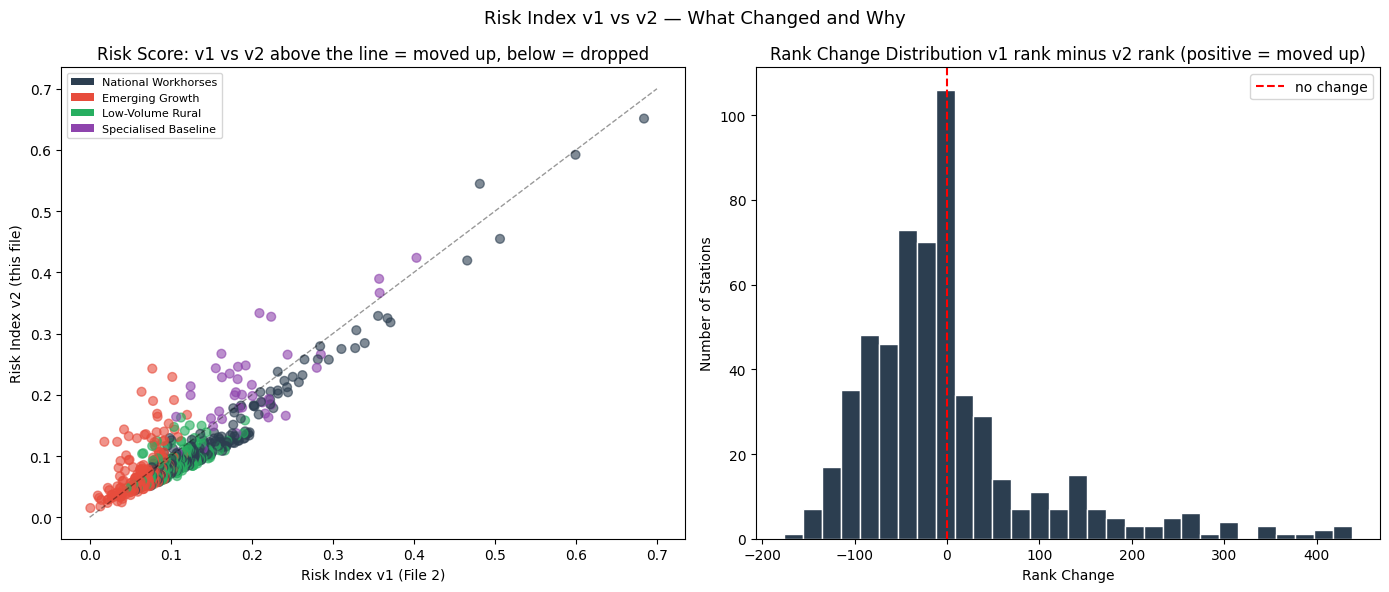


Most stations do not move much — the core ranking is stable
The stations that do move are where the forecast signal is meaningfully different
from what the historical growth rate alone would suggest


In [30]:
# scatter plot v1 vs v2 and rank change distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: v1 score vs v2 score - coloured by cluster
colors_map = decision_table['strategy_cluster'].map({
    'National Workhorses':  '#2C3E50',
    'Emerging Growth':      '#E74C3C',
    'Low-Volume Rural':     '#27AE60',
    'Specialised Baseline': '#8E44AD'
})
axes[0].scatter(decision_table['risk_index'], decision_table['risk_index_v2'],
                c=colors_map, alpha=0.6, s=40)
axes[0].plot([0, 0.7], [0, 0.7], 'k--', linewidth=1, alpha=0.4, label='no change line')
axes[0].set_title('Risk Score: v1 vs v2 above the line = moved up, below = dropped')
axes[0].set_xlabel('Risk Index v1 (File 2)')
axes[0].set_ylabel('Risk Index v2 (this file)')
legend_els = [
    Patch(facecolor='#2C3E50', label='National Workhorses'),
    Patch(facecolor='#E74C3C', label='Emerging Growth'),
    Patch(facecolor='#27AE60', label='Low-Volume Rural'),
    Patch(facecolor='#8E44AD', label='Specialised Baseline')
]
axes[0].legend(handles=legend_els, fontsize=8)
axes[0].grid(False)

# right: how many places did stations move
axes[1].hist(decision_table['rank_change'], bins=30, color='#2C3E50', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='no change')
axes[1].set_title('Rank Change Distribution v1 rank minus v2 rank (positive = moved up)')
axes[1].set_xlabel('Rank Change')
axes[1].set_ylabel('Number of Stations')
axes[1].legend()
axes[1].grid(False)

plt.suptitle('Risk Index v1 vs v2 — What Changed and Why', fontsize=13)
plt.tight_layout()
plt.show()

print()
print('Most stations do not move much — the core ranking is stable')
print('The stations that do move are where the forecast signal is meaningfully different')
print('from what the historical growth rate alone would suggest')

---
## Section 4 — Risk Tiers

Grouping every station into one of four tiers based on their Risk Index v2 rank. This makes the output more usable — instead of a ranked list of 564 stations, planners get four clear priority groups.

| Tier | Cut-off | Number of stations |
|---|---|---|
| Critical | Top 10% | ~57 stations |
| High | Next 20% | ~113 stations |
| Moderate | Next 40% | ~226 stations |
| Stable | Bottom 30% | ~168 stations |

In [31]:
total_stations = len(decision_table)

def get_tier(rank):
    if rank <= total_stations * 0.10:
        return 'Critical'
    elif rank <= total_stations * 0.30:
        return 'High'
    elif rank <= total_stations * 0.70:
        return 'Moderate'
    else:
        return 'Stable'

decision_table['risk_tier'] = decision_table['rank_v2'].apply(get_tier)

print('Risk tier counts:')
print(decision_table['risk_tier'].value_counts())
print()
print('Tier breakdown by cluster:')
display(pd.crosstab(decision_table['strategy_cluster'], decision_table['risk_tier']))

Risk tier counts:
risk_tier
Moderate    225
Stable      170
High        113
Critical     56
Name: count, dtype: int64

Tier breakdown by cluster:


risk_tier,Critical,High,Moderate,Stable
strategy_cluster,,,,
Emerging Growth,5,21,45,121
Low-Volume Rural,0,24,95,31
National Workhorses,28,55,83,18
Specialised Baseline,23,13,2,0


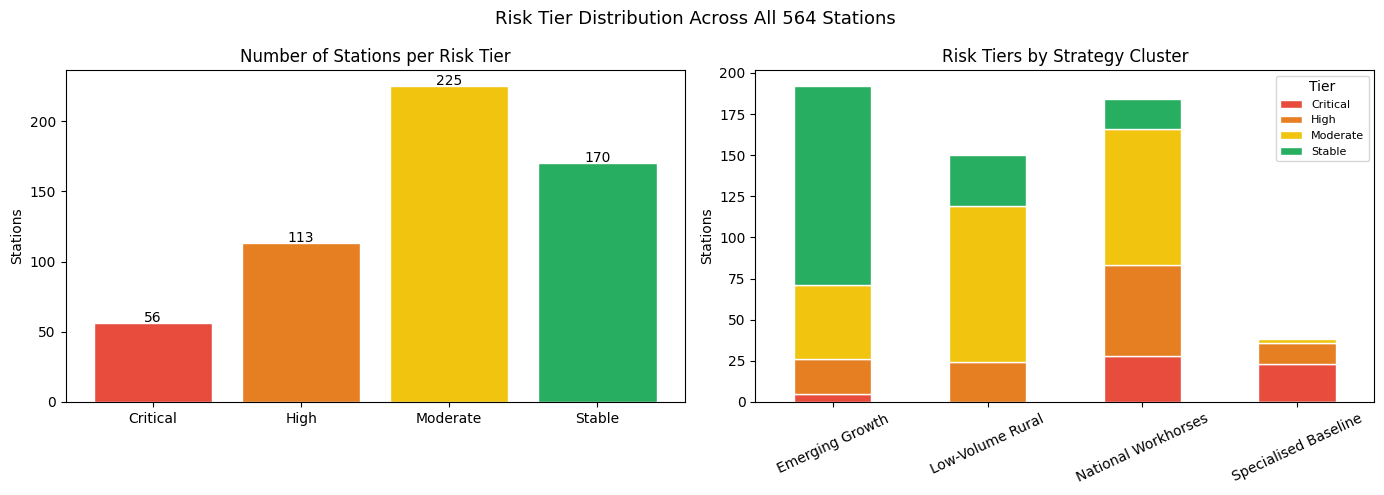

In [32]:
# two charts - tier counts and tier breakdown by cluster

tier_order  = ['Critical', 'High', 'Moderate', 'Stable']
tier_colors = ['#E74C3C', '#E67E22', '#F1C40F', '#27AE60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: how many stations in each tier
tier_counts = decision_table['risk_tier'].value_counts().reindex(tier_order)
axes[0].bar(tier_order, tier_counts.values, color=tier_colors, edgecolor='white')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)
axes[0].set_title('Number of Stations per Risk Tier')
axes[0].set_ylabel('Stations')
axes[0].grid(False)

# right: which clusters dominate each tier
ct = decision_table.groupby(['strategy_cluster', 'risk_tier']).size().unstack(fill_value=0)
ct = ct.reindex(columns=tier_order, fill_value=0)
ct.plot(kind='bar', ax=axes[1], color=tier_colors, edgecolor='white', stacked=True)
axes[1].set_title('Risk Tiers by Strategy Cluster')
axes[1].set_xlabel('')
axes[1].set_ylabel('Stations')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Tier', fontsize=8)
axes[1].grid(False)

plt.suptitle('Risk Tier Distribution Across All 564 Stations', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — National Top 20 Priority Stations

Pure risk-based selection. Take the 20 highest scoring stations by Risk Index v2 regardless of location. This answers the question: if you could only focus resources on 20 stations nationally, which ones would they be?

In [33]:
# top 20 by risk index v2
national_top20 = decision_table.sort_values('rank_v2').head(20).copy()

print('National Top 20 Priority Stations')
print()
display(national_top20[[
    'station_name', 'county', 'strategy_cluster', 'risk_tier',
    'risk_index_v2', 'rank_v2', 'forecast_2025', 'warning_score'
]].reset_index(drop=True))

National Top 20 Priority Stations



,station_name,county,strategy_cluster,risk_tier,risk_index_v2,rank_v2,forecast_2025,warning_score
0,Store Street,Dublin,National Workhorses,Critical,0.651317,1,12071.0,1
1,Pearse Street,Dublin,National Workhorses,Critical,0.592215,2,10339.0,1
2,Bridewell Dublin,Dublin,National Workhorses,Critical,0.544758,3,8065.0,1
3,Blanchardstown,Dublin,National Workhorses,Critical,0.454811,4,7920.0,1
4,Ballyporeen,Tipperary,Specialised Baseline,Critical,0.423877,5,87.0,1
5,Tallaght,Dublin,National Workhorses,Critical,0.419441,6,7226.0,1
6,Nenagh,Tipperary,Specialised Baseline,Critical,0.389544,7,1232.0,1
7,An Spideal,Galway,Specialised Baseline,Critical,0.366563,8,123.0,0
8,Ardrahan,Galway,Specialised Baseline,Critical,0.333508,9,186.0,1
9,Henry Street,Limerick,National Workhorses,Critical,0.328972,10,5078.0,1


In [34]:
# what share of national crime do these 20 stations account for?

total_recent  = decision_table['incidents_recent'].sum()
top20_recent  = national_top20['incidents_recent'].sum()
top20_pct     = top20_recent / total_recent * 100

dublin_count    = national_top20['county'].str.contains('Dublin', na=False).sum()
nondublin_count = len(national_top20) - dublin_count

print('Coverage Summary — National Top 20')
print(f'These 20 stations account for {top20_pct:.1f}% of all national incidents')
print(f'Dublin stations     : {dublin_count}')
print(f'Non-Dublin stations : {nondublin_count}')
print()
print('Cluster breakdown:')
print(national_top20['strategy_cluster'].value_counts())
print()
print('Counties:')
print(national_top20['county'].value_counts())

Coverage Summary — National Top 20
These 20 stations account for 28.1% of all national incidents
Dublin stations     : 11
Non-Dublin stations : 9

Cluster breakdown:
strategy_cluster
National Workhorses     13
Specialised Baseline     7
Name: count, dtype: int64

Counties:
county
Dublin       11
Galway        3
Tipperary     2
Limerick      1
Wicklow       1
Waterford     1
Kerry         1
Name: count, dtype: int64


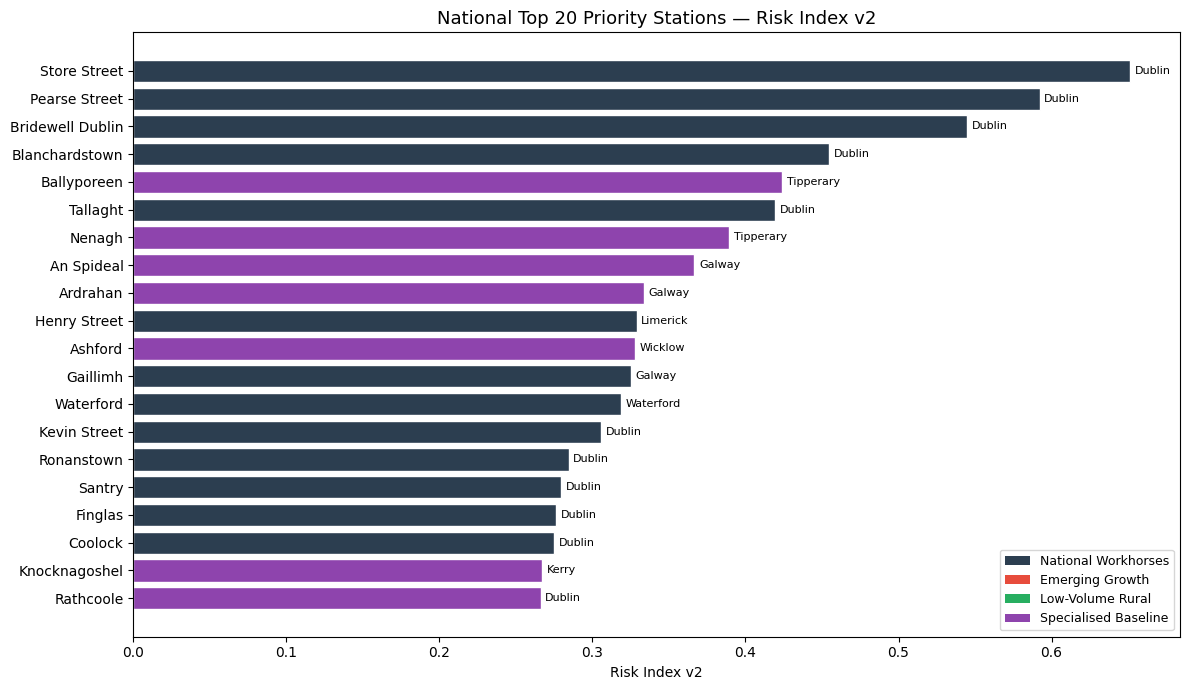

In [35]:
# horizontal bar chart - one bar per station coloured by cluster

fig, ax = plt.subplots(figsize=(12, 7))

bar_colors = national_top20['strategy_cluster'].map({
    'National Workhorses':  '#2C3E50',
    'Emerging Growth':      '#E74C3C',
    'Low-Volume Rural':     '#27AE60',
    'Specialised Baseline': '#8E44AD'
})

ax.barh(national_top20['station_name'], national_top20['risk_index_v2'],
        color=bar_colors, edgecolor='white')
ax.set_title('National Top 20 Priority Stations — Risk Index v2', fontsize=13)
ax.set_xlabel('Risk Index v2')
ax.invert_yaxis()

# add county name at end of each bar
for i, (_, row) in enumerate(national_top20.iterrows()):
    ax.text(row['risk_index_v2'] + 0.003, i, row['county'], va='center', fontsize=8)

ax.legend(handles=legend_els, fontsize=9, loc='lower right')
ax.grid(False)
plt.tight_layout()
plt.show()

---
## Section 6 — High Risk Stations Outside Dublin

A common planning mistake is focusing only on Dublin because it dominates the raw volume numbers. This scenario filters Dublin out completely to surface high-risk stations elsewhere in Ireland.

This answers the question: if we ran a Dublin-only strategy, which important stations would we miss?

In [36]:
# take the top 50 by risk index v2 and remove any Dublin stations
top50_v2   = decision_table.sort_values('rank_v2').head(50)
outside_dublin = top50_v2[~top50_v2['county'].str.contains('Dublin', na=False)].copy()

print('High Risk Stations Outside Dublin (from top 50)')
print()
display(outside_dublin[[
    'station_name', 'county', 'strategy_cluster', 'risk_tier',
    'risk_index_v2', 'rank_v2', 'forecast_2025', 'warning_score'
]].reset_index(drop=True))

High Risk Stations Outside Dublin (from top 50)



,station_name,county,strategy_cluster,risk_tier,risk_index_v2,rank_v2,forecast_2025,warning_score
0,Ballyporeen,Tipperary,Specialised Baseline,Critical,0.423877,5,87.0,1
1,Nenagh,Tipperary,Specialised Baseline,Critical,0.389544,7,1232.0,1
2,An Spideal,Galway,Specialised Baseline,Critical,0.366563,8,123.0,0
3,Ardrahan,Galway,Specialised Baseline,Critical,0.333508,9,186.0,1
4,Henry Street,Limerick,National Workhorses,Critical,0.328972,10,5078.0,1
5,Ashford,Wicklow,Specialised Baseline,Critical,0.327607,11,828.0,2
6,Gaillimh,Galway,National Workhorses,Critical,0.325173,12,5324.0,1
7,Waterford,Waterford,National Workhorses,Critical,0.318469,13,5026.0,1
8,Knocknagoshel,Kerry,Specialised Baseline,Critical,0.267155,19,NaN,0
9,Holycross,Tipperary,Specialised Baseline,Critical,0.265657,21,74.0,0


In [37]:
# coverage

od_recent = outside_dublin['incidents_recent'].sum()
od_pct    = od_recent / total_recent * 100

print('Coverage Summary — Outside Dublin')
print(f'These stations account for {od_pct:.1f}% of national incidents')
print(f'Stations selected: {len(outside_dublin)}')
print()
print('County breakdown:')
print(outside_dublin['county'].value_counts())
print()
print('Cluster breakdown:')
print(outside_dublin['strategy_cluster'].value_counts())
print()
print('A Dublin-only strategy would miss all of these stations')

Coverage Summary — Outside Dublin
These stations account for 16.0% of national incidents
Stations selected: 32

County breakdown:
county
Galway                4
Tipperary             3
Waterford             3
Kerry                 3
Louth                 3
Kildare               2
Limerick              2
Laois/Offaly          2
Cork                  2
Westmeath             2
Mayo                  2
Wicklow               1
Roscommon/Longford    1
Wexford               1
Meath                 1
Name: count, dtype: int64

Cluster breakdown:
strategy_cluster
Specialised Baseline    18
National Workhorses     11
Emerging Growth          3
Name: count, dtype: int64

A Dublin-only strategy would miss all of these stations


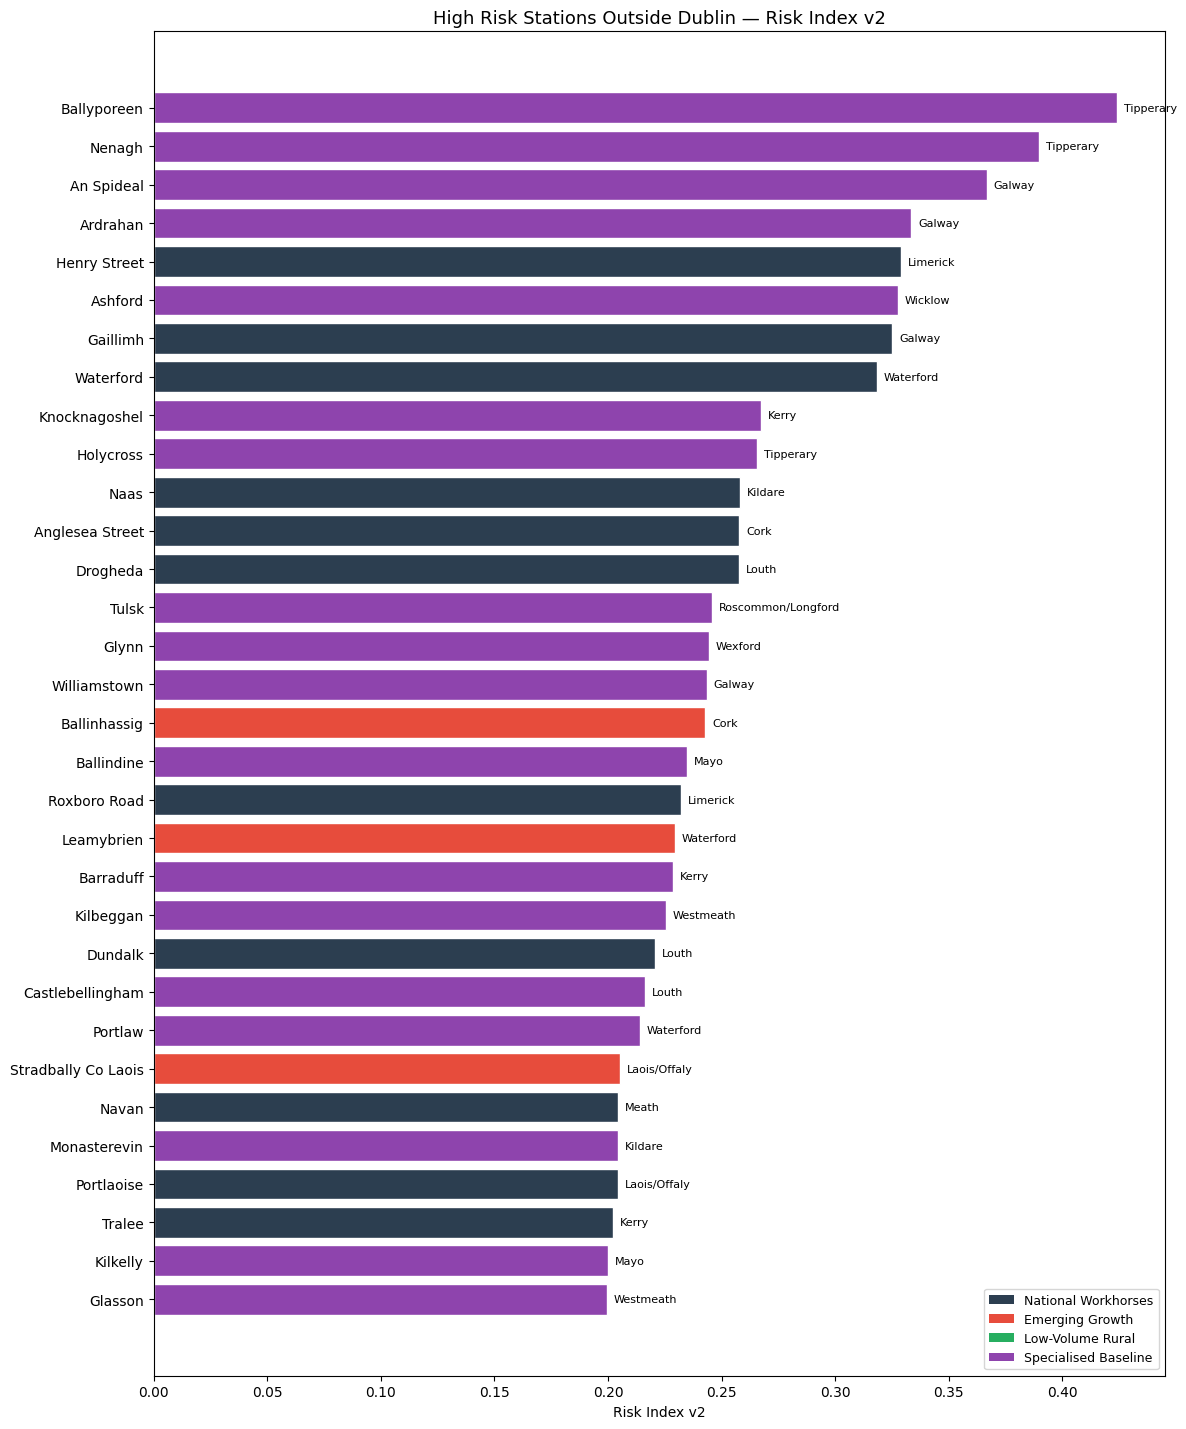

In [38]:
# bar chart for outside Dublin stations

fig, ax = plt.subplots(figsize=(12, max(5, len(outside_dublin) * 0.45)))

bar_colors_od = outside_dublin['strategy_cluster'].map({
    'National Workhorses':  '#2C3E50',
    'Emerging Growth':      '#E74C3C',
    'Low-Volume Rural':     '#27AE60',
    'Specialised Baseline': '#8E44AD'
})

ax.barh(outside_dublin['station_name'], outside_dublin['risk_index_v2'],
        color=bar_colors_od, edgecolor='white')
ax.set_title('High Risk Stations Outside Dublin — Risk Index v2', fontsize=13)
ax.set_xlabel('Risk Index v2')
ax.invert_yaxis()

for i, (_, row) in enumerate(outside_dublin.iterrows()):
    ax.text(row['risk_index_v2'] + 0.003, i, row['county'], va='center', fontsize=8)

ax.legend(handles=legend_els, fontsize=9, loc='lower right')
ax.grid(False)
plt.tight_layout()
plt.show()

---
## Section 7 — Emerging Pressure Stations

These are stations that are not yet in the Critical tier but are showing all the early warning signs. The idea is to catch them before they become a problem rather than responding after the fact.

Three conditions must all be true at the same time:
1. The station is in the **Emerging Growth** cluster — it has a history of growing crime volume
2. **Growth Alert = 1** — forecast 2025 is more than 15% above recent average
3. **Warning Score = 2** — both growth and pressure alerts are active

Stations meeting all three conditions are the highest-leverage early intervention targets.

In [39]:
# find stations meeting all 3 conditions
emerging_pressure = decision_table[
    (decision_table['strategy_cluster'] == 'Emerging Growth') &
    (decision_table['growth_alert']     == 1) &
    (decision_table['warning_score']    == 2)
].sort_values('rank_v2').copy()

print(f'Stations meeting all 3 conditions: {len(emerging_pressure)}')
print()

if len(emerging_pressure) > 0:
    display(emerging_pressure[[
        'station_name', 'county', 'risk_tier', 'risk_index_v2', 'rank_v2',
        'forecast_2025', 'growth_alert', 'pressure_alert', 'warning_score'
    ]].reset_index(drop=True))
else:
    # relax to just emerging growth + at least one alert
    print('No stations meet all 3 strict conditions')
    print('Relaxing to: Emerging Growth cluster + warning_score >= 1')
    print()
    emerging_pressure = decision_table[
        (decision_table['strategy_cluster'] == 'Emerging Growth') &
        (decision_table['warning_score']    >= 1)
    ].sort_values('rank_v2').copy()
    print(f'Stations with relaxed conditions: {len(emerging_pressure)}')
    display(emerging_pressure[[
        'station_name', 'county', 'risk_tier', 'risk_index_v2', 'rank_v2',
        'forecast_2025', 'growth_alert', 'pressure_alert', 'warning_score'
    ]].reset_index(drop=True))

Stations meeting all 3 conditions: 0

No stations meet all 3 strict conditions
Relaxing to: Emerging Growth cluster + warning_score >= 1

Stations with relaxed conditions: 0


,station_name,county,risk_tier,risk_index_v2,rank_v2,forecast_2025,growth_alert,pressure_alert,warning_score


In [40]:
# coverage for emerging pressure stations
if len(emerging_pressure) > 0:
    ep_recent = emerging_pressure['incidents_recent'].sum()
    ep_pct    = ep_recent / total_recent * 100

    print('Coverage Summary — Emerging Pressure Stations')
    print(f'Stations selected       : {len(emerging_pressure)}')
    print(f'% of national incidents : {ep_pct:.1f}%')
    print()
    print('Tier breakdown (most should be High or Moderate — not Critical yet):')
    print(emerging_pressure['risk_tier'].value_counts())
    print()
    print('County breakdown:')
    print(emerging_pressure['county'].value_counts())

---
## Section 8 — Scenario Comparison & Analyst Recommendation

In [41]:
# build a clean comparison table across all 3 scenarios

def summarise(df, label):
    if len(df) == 0:
        return {'Scenario': label, 'Stations': 0,
                'Pct National Incidents': 0, 'Dublin': 0,
                'Non-Dublin': 0, 'Critical Tier': 0,
                'High Tier': 0, 'Avg Warning Score': 0}
    dublin = df['county'].str.contains('Dublin', na=False).sum()
    return {
        'Scenario':                label,
        'Stations':                len(df),
        'Pct National Incidents':  round(df['incidents_recent'].sum() / total_recent * 100, 1),
        'Dublin':                  dublin,
        'Non-Dublin':              len(df) - dublin,
        'Critical Tier':           (df['risk_tier'] == 'Critical').sum(),
        'High Tier':               (df['risk_tier'] == 'High').sum(),
        'Avg Warning Score':       round(df['warning_score'].mean(), 2)
    }

comparison = pd.DataFrame([
    summarise(national_top20,    'National Top 20'),
    summarise(outside_dublin,    'Outside Dublin'),
    summarise(emerging_pressure, 'Emerging Pressure')
])

print('Scenario Comparison')
display(comparison.set_index('Scenario'))

Scenario Comparison


,Stations,Pct National Incidents,Dublin,Non-Dublin,Critical Tier,High Tier,Avg Warning Score
Scenario,,,,,,,
National Top 20,20,28.1,11,9,20,0,1.00
Outside Dublin,32,16.0,0,32,32,0,0.56
Emerging Pressure,0,0.0,0,0,0,0,0.00


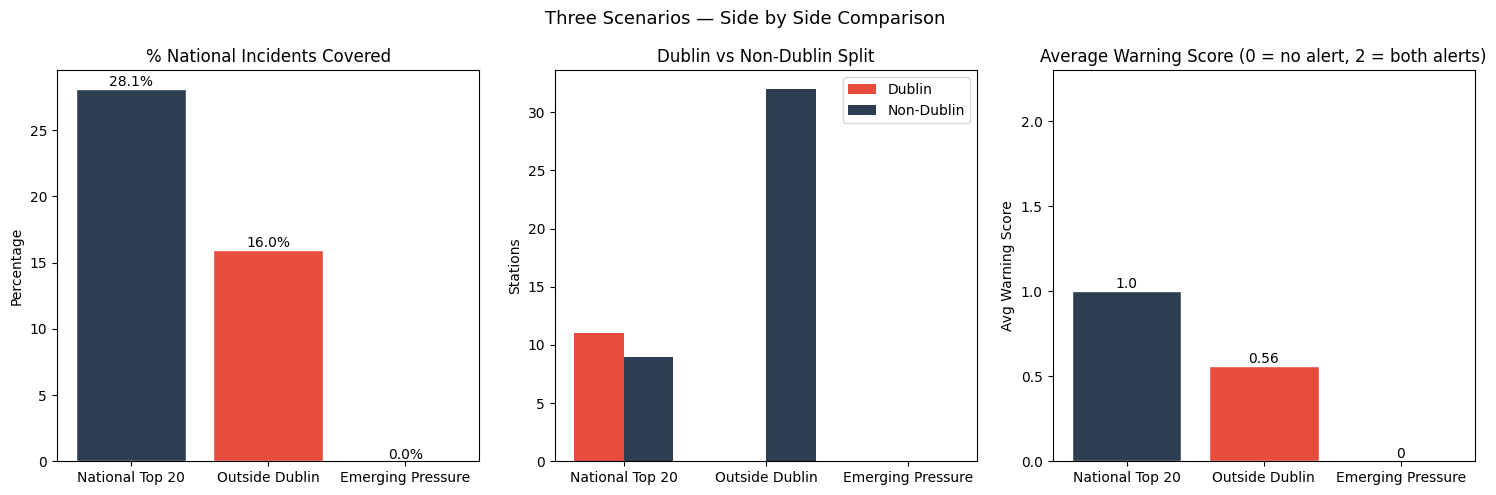

In [42]:
# visual comparison across all 3 scenarios

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scenario_labels = ['National Top 20', 'Outside Dublin', 'Emerging Pressure']
scenario_colors = ['#2C3E50', '#E74C3C', '#27AE60']

# pct of national incidents
pcts = [
    national_top20['incidents_recent'].sum() / total_recent * 100,
    outside_dublin['incidents_recent'].sum() / total_recent * 100,
    emerging_pressure['incidents_recent'].sum() / total_recent * 100 if len(emerging_pressure) > 0 else 0
]
axes[0].bar(scenario_labels, pcts, color=scenario_colors, edgecolor='white')
for i, v in enumerate(pcts):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)
axes[0].set_title('% National Incidents Covered')
axes[0].set_ylabel('Percentage')
axes[0].grid(False)

# dublin vs non-dublin
dub = [
    national_top20['county'].str.contains('Dublin', na=False).sum(),
    outside_dublin['county'].str.contains('Dublin', na=False).sum(),
    emerging_pressure['county'].str.contains('Dublin', na=False).sum() if len(emerging_pressure) > 0 else 0
]
nondub = [len(national_top20) - dub[0],
          len(outside_dublin)  - dub[1],
          len(emerging_pressure) - dub[2] if len(emerging_pressure) > 0 else 0]
x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, dub,    width=w, label='Dublin',     color='#E74C3C')
axes[1].bar(x + w/2, nondub, width=w, label='Non-Dublin', color='#2C3E50')
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenario_labels)
axes[1].set_title('Dublin vs Non-Dublin Split')
axes[1].set_ylabel('Stations')
axes[1].legend()
axes[1].grid(False)

# avg warning score
avg_ws = [
    round(national_top20['warning_score'].mean(), 2),
    round(outside_dublin['warning_score'].mean(), 2),
    round(emerging_pressure['warning_score'].mean(), 2) if len(emerging_pressure) > 0 else 0
]
axes[2].bar(scenario_labels, avg_ws, color=scenario_colors, edgecolor='white')
for i, v in enumerate(avg_ws):
    axes[2].text(i, v + 0.02, str(v), ha='center', fontsize=10)
axes[2].set_title('Average Warning Score (0 = no alert, 2 = both alerts)')
axes[2].set_ylabel('Avg Warning Score')
axes[2].set_ylim(0, 2.3)
axes[2].grid(False)

plt.suptitle('Three Scenarios — Side by Side Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---
## Analyst Recommendation

**National Top 20** is the right starting point for any national resource review. These 20 stations account for a disproportionate share of all national incidents and represent the highest combined risk across volume, growth, forecast, and crime complexity signals. Any resource planning exercise should start here.

**Outside Dublin** should run alongside the Top 20, not instead of it. The stations surfaced here are high risk by every metric but would be invisible in a Dublin-centric planning process. Several of these are in the Emerging Growth cluster which means their current volume understates where they are heading. These are the stations most at risk of being overlooked.

**Emerging Pressure** is the most forward-looking of the three. These stations are not yet in the Critical tier but they meet every early warning condition at the same time — they are growing fast, forecast to keep growing, and already above the national pressure threshold. The cost of acting early here is much lower than responding reactively once they reach Critical tier.

**Recommended approach for planners:**
- Use the National Top 20 for immediate resource review
- Use Outside Dublin to ensure geographic balance in the plan
- Use Emerging Pressure as the watchlist for the next planning cycle — these are tomorrow's problem stations

---
## Save All Outputs

In [43]:
from google.colab import files

# master decision table - all 564 stations with every metric
decision_table.to_csv('station_decision_table.csv', index=False)
print('saved station_decision_table.csv —', len(decision_table), 'rows')

# risk index v2 scores and tiers
v2_out = decision_table[[
    'station_code', 'station_name', 'county', 'strategy_cluster',
    'risk_index', 'rank_risk',
    'risk_index_v2', 'rank_v2', 'rank_change',
    'risk_tier', 'warning_score'
]].sort_values('rank_v2').copy()
v2_out.to_csv('station_risk_index_v2.csv', index=False)
print('saved station_risk_index_v2.csv —', len(v2_out), 'rows')

# scenario outputs - named clearly so anyone knows what they contain
national_top20.to_csv('priority_stations_national_top20.csv', index=False)
print('saved priority_stations_national_top20.csv —', len(national_top20), 'rows')

outside_dublin.to_csv('priority_stations_outside_dublin.csv', index=False)
print('saved priority_stations_outside_dublin.csv —', len(outside_dublin), 'rows')

emerging_pressure.to_csv('priority_stations_emerging_pressure.csv', index=False)
print('saved priority_stations_emerging_pressure.csv —', len(emerging_pressure), 'rows')

print()
files.download('station_decision_table.csv')
files.download('station_risk_index_v2.csv')
files.download('priority_stations_national_top20.csv')
files.download('priority_stations_outside_dublin.csv')
files.download('priority_stations_emerging_pressure.csv')

saved station_decision_table.csv — 564 rows
saved station_risk_index_v2.csv — 564 rows
saved priority_stations_national_top20.csv — 20 rows
saved priority_stations_outside_dublin.csv — 32 rows
saved priority_stations_emerging_pressure.csv — 0 rows



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary

**What we built in this file:**
- Master decision table combining all outputs from Files 1–6 into one 564-station table
- Risk Index v2 — improved over v1 by adding forecast growth and offence concentration as new signals
- Risk tiers assigning every station to Critical / High / Moderate / Stable
- Three scenario simulations answering three different planning questions

**Why Risk Index v2 is better than v1:**
v1 only used past volume and past growth rate — it was entirely backwards-looking. v2 adds what we expect to happen in 2025 and how operationally complex each station is. Stations that are growing fast and forecast to keep growing move up. Stations that were historically busy but are now flat move down slightly. The ranking becomes more honest.

**Key message:**
No single scenario is the complete answer. The three scenarios are designed to complement each other — national coverage, geographic balance, and early intervention. A planner using all three together gets a fuller picture than any one scenario alone could give.